In [624]:
%pip install scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [625]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

## EDA

In [626]:
file_features_path = f'../data/feet_dataset_clean.csv'
file_labels_path = f'../data/feet_labels.csv'

feet_features_df = pd.read_csv(file_features_path)
feet_features_df.shape

(757, 7)

In [627]:
feet_features_df = feet_features_df[ feet_features_df['bad_photo'] != 1 ]
feet_features_df

,img_name,width,height,coin_width,coin_height,foot_width,bad_photo
0,43_paulo_left_2.jpeg,1280,960,123,122,1061,0
1,43_paulo_left_3.jpeg,1280,960,118,116,1032,0
2,43_paulo_left_4.jpeg,1280,960,113,112,988,0
3,43_paulo_left_8.jpeg,1280,960,110,108,1025,0
4,43_paulo_left_9.jpeg,1280,960,109,107,1022,0
...,...,...,...,...,...,...,...
751,37_angelica_left_12.jpeg,1600,1200,173,174,1412,0
753,37_angelica_left_6.jpeg,1600,1200,146,149,1219,0
754,37_angelica_left_15.jpeg,1600,1200,163,163,1333,0
755,37_angelica_left_7.jpeg,1600,1200,146,149,1220,0


In [628]:
# feet_features_df = feet_features_df[ feet_features_df['bad_photo'] == -1 ]
# feet_features_df

#### Merge features and labels dataframes

In [629]:
feet_labels_df = pd.read_csv(file_labels_path)
feet_labels_df.tail(5)

,name,sex,foot_side,size_cm,size_eu
38,44_juanz_right,M,right,27.8,44
39,45_gian_right,M,right,28.8,45
40,35_mary_right,F,right,22.0,35
41,37_rosamaria_right,F,right,23.0,37
42,37_angelica_left,F,left,23.9,37


In [630]:
# Crear una copia explícita del DataFrame para trabajar
feet_features_df = feet_features_df.copy()

# Limpia la extensión de los nombres
feet_features_df['img_name_clean'] = feet_features_df['img_name'].str.rsplit('.', n=1).str[0]

# Aplica la transformación adicional con lambda
feet_features_df['img_name_clean'] = feet_features_df['img_name_clean'].apply(
    lambda x: '_'.join(x.split('_')[:-1]) if x.split('_')[-1].isdigit() else x
)

feet_features_df

,img_name,width,height,coin_width,coin_height,foot_width,bad_photo,img_name_clean
0,43_paulo_left_2.jpeg,1280,960,123,122,1061,0,43_paulo_left
1,43_paulo_left_3.jpeg,1280,960,118,116,1032,0,43_paulo_left
2,43_paulo_left_4.jpeg,1280,960,113,112,988,0,43_paulo_left
3,43_paulo_left_8.jpeg,1280,960,110,108,1025,0,43_paulo_left
4,43_paulo_left_9.jpeg,1280,960,109,107,1022,0,43_paulo_left
...,...,...,...,...,...,...,...,...
751,37_angelica_left_12.jpeg,1600,1200,173,174,1412,0,37_angelica_left
753,37_angelica_left_6.jpeg,1600,1200,146,149,1219,0,37_angelica_left
754,37_angelica_left_15.jpeg,1600,1200,163,163,1333,0,37_angelica_left
755,37_angelica_left_7.jpeg,1600,1200,146,149,1220,0,37_angelica_left


In [631]:
full_feet_df = pd.merge(feet_features_df, feet_labels_df, how='left', left_on='img_name_clean', right_on='name')
full_feet_df

,img_name,width,height,coin_width,coin_height,foot_width,bad_photo,img_name_clean,name,sex,foot_side,size_cm,size_eu
0,43_paulo_left_2.jpeg,1280,960,123,122,1061,0,43_paulo_left,43_paulo_left,M,left,27.2,43
1,43_paulo_left_3.jpeg,1280,960,118,116,1032,0,43_paulo_left,43_paulo_left,M,left,27.2,43
2,43_paulo_left_4.jpeg,1280,960,113,112,988,0,43_paulo_left,43_paulo_left,M,left,27.2,43
3,43_paulo_left_8.jpeg,1280,960,110,108,1025,0,43_paulo_left,43_paulo_left,M,left,27.2,43
4,43_paulo_left_9.jpeg,1280,960,109,107,1022,0,43_paulo_left,43_paulo_left,M,left,27.2,43
...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,37_angelica_left_12.jpeg,1600,1200,173,174,1412,0,37_angelica_left,37_angelica_left,F,left,23.9,37
616,37_angelica_left_6.jpeg,1600,1200,146,149,1219,0,37_angelica_left,37_angelica_left,F,left,23.9,37
617,37_angelica_left_15.jpeg,1600,1200,163,163,1333,0,37_angelica_left,37_angelica_left,F,left,23.9,37
618,37_angelica_left_7.jpeg,1600,1200,146,149,1220,0,37_angelica_left,37_angelica_left,F,left,23.9,37


In [632]:
full_feet_df.isnull().sum()

img_name          0
width             0
height            0
coin_width        0
coin_height       0
foot_width        0
bad_photo         0
img_name_clean    0
name              0
sex               0
foot_side         0
size_cm           0
size_eu           0
dtype: int64

In [633]:
full_feet_df[full_feet_df['name'].isnull()]

,img_name,width,height,coin_width,coin_height,foot_width,bad_photo,img_name_clean,name,sex,foot_side,size_cm,size_eu


In [634]:
sel_columns = ["width", "height", "coin_width", "coin_height", "foot_width", "sex", "foot_side", "size_cm"]
feet_df = full_feet_df[sel_columns]

In [635]:
feet_df.sample(frac=1).head(10)

,width,height,coin_width,coin_height,foot_width,sex,foot_side,size_cm
158,1600,1200,112,113,1013,M,left,26.2
506,1600,1200,145,140,1458,M,right,28.8
556,1600,1200,153,159,1162,F,right,22.8
562,1600,1200,115,115,928,F,right,22.8
226,1280,720,112,126,1066,F,left,23.4
543,1600,1200,182,184,1325,F,right,22.8
88,1600,1200,158,160,1427,M,left,27.5
208,1600,1200,164,165,1421,M,left,26.0
0,1280,960,123,122,1061,M,left,27.2
465,1600,717,86,86,885,M,left,27.0


In [636]:
feet_df['sex'].value_counts()

sex
M    343
F    277
Name: count, dtype: int64

In [637]:
feet_df.describe()

,width,height,coin_width,coin_height,foot_width,size_cm
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000
mean,1526.325806,1092.791935,136.246774,138.254839,1179.427419,25.154194
std,132.340496,193.102709,26.073317,26.410569,190.058947,1.868556
min,1280.000000,584.000000,73.000000,74.000000,684.000000,21.700000
25%,1600.000000,960.000000,117.000000,118.000000,1036.000000,23.500000
50%,1600.000000,1200.000000,135.000000,139.000000,1187.000000,25.500000
75%,1600.000000,1200.000000,157.000000,159.000000,1339.250000,26.500000
max,1600.000000,1600.000000,202.000000,207.000000,1542.000000,28.800000


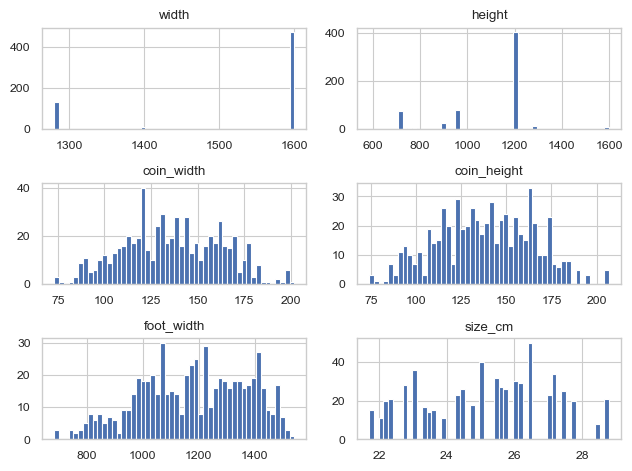

In [638]:
feet_df.hist(bins=50)
plt.tight_layout()
plt.show()

In [639]:
full_feet_df[full_feet_df['width'] >= 2000]

,img_name,width,height,coin_width,coin_height,foot_width,bad_photo,img_name_clean,name,sex,foot_side,size_cm,size_eu


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0.5, 0, 'width'),
  Text(1.5, 0, 'height'),
  Text(2.5, 0, 'coin_width'),
  Text(3.5, 0, 'coin_height'),
  Text(4.5, 0, 'foot_width'),
  Text(5.5, 0, 'size_cm'),
  Text(6.5, 0, 'sex_M'),
  Text(7.5, 0, 'foot_side_right')])

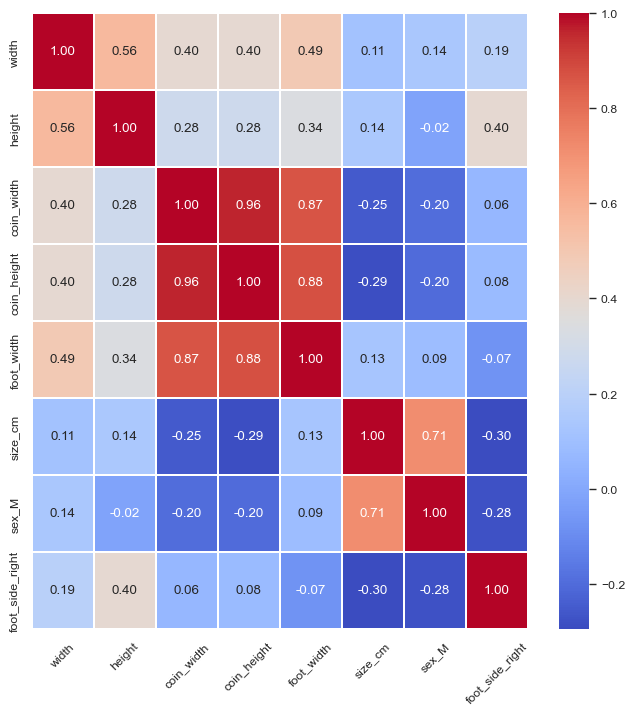

In [640]:
import seaborn as sns 

feet_encoded = pd.get_dummies(feet_df, columns=['sex', 'foot_side'],  drop_first=True)

corr_matrix = feet_encoded.corr()

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(8, 8))
ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=.3, cmap='coolwarm')
plt.xticks(rotation=45)

In [641]:
feet_encoded.head(5)

,width,height,coin_width,coin_height,foot_width,size_cm,sex_M,foot_side_right
0,1280,960,123,122,1061,27.2,True,False
1,1280,960,118,116,1032,27.2,True,False
2,1280,960,113,112,988,27.2,True,False
3,1280,960,110,108,1025,27.2,True,False
4,1280,960,109,107,1022,27.2,True,False


## Training a linear model

In [642]:
MODEL_RESULTS = []

In [643]:
# def get_linear_metrics(model, X_test, y_test):
#     y_pred = model.predict(X_test)
#     r_squared = model.score(X_test, y_test)
#     mse = mean_squared_error(y_test, y_pred)
#     # r2 = r2_score(y_test, y_pred)

#     print(f"R²: {r_squared}") # same r2_score(y_test, y_pred) = model.score(X_test, y_test)
#     print(f"MSE: {mse}")
#     print(f"Coeficients: {model.coef_}")
#     print(f"Intercept: {model.intercept_}")

def collect_metrics(model_name, y_pred, y_test):
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"-------model: {model_name}-------")
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print()
    MODEL_RESULTS.append({"model_name": model_name, "r2": r2, "mse": mse, "rmse": rmse})


In [644]:

X = feet_encoded.drop(columns=['size_cm'])
y = feet_encoded["size_cm"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=32, shuffle=True)

# Escalar características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# get_linear_metrics(model, X_test, y_test)
collect_metrics("LinearRegression", y_pred, y_test)

-------model: LinearRegression-------
R²: 0.8105
MSE: 0.6201
RMSE: 0.7875



#### Inference

In [645]:
print("predictions:", list(y_pred[:5]))
print("ground-truth values:", list(y_test[:5].values))

predictions: [25.248969602564742, 23.875958774597333, 23.370648202583716, 27.26998518046857, 23.625735682308893]
ground-truth values: [24.3, 22.2, 23.0, 27.2, 23.4]


#### Plotting

In [646]:
# plt.figure(figsize=(8,6))
# plt.scatter(range(len(y_test)), y_test, color='blue', label='Ground-Truth Values')
# plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predictions')
# plt.xlabel("index")
# plt.ylabel("size_cm")
# plt.legend()
# plt.grid(True)
# plt.show()

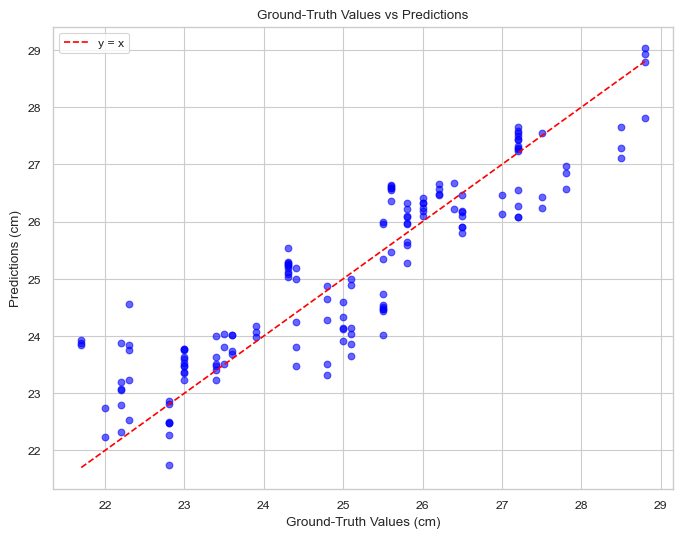

In [647]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='y = x')
plt.title("Ground-Truth Values vs Predictions")
plt.xlabel("Ground-Truth Values (cm)")
plt.ylabel("Predictions (cm)")
plt.legend()
plt.grid(True)

### Aplying Cross-Validation

In [648]:
from sklearn.model_selection import cross_val_score, KFold

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='r2')

print("R² per fold:", cv_scores)
print("R² average:", cv_scores.mean())

R² per fold: [0.82850175 0.5838361  0.82457258 0.80344628 0.82159371]
R² average: 0.7723900823943763


In [649]:
model.fit(X_scaled, y)
y_pred = model.predict(X_test)

# get_linear_metrics(model, X_test, y_test)
collect_metrics("LinearRegression-CV", y_pred, y_test)

print("predictions:", list(y_pred[:5]))
print("ground-truth values:", list(y_test[:5].values))

-------model: LinearRegression-CV-------
R²: 0.8233
MSE: 0.5783
RMSE: 0.7605

predictions: [25.088725964109646, 23.7584549593786, 23.31728310780512, 27.233219448210775, 23.673446502500685]
ground-truth values: [24.3, 22.2, 23.0, 27.2, 23.4]


Small improvement. Let's try with another approach

### Aplying Polynomial Regression with Cross Validation

In [650]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

max_degree = 5
# results = []
for degree in range(1, max_degree):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=degree)),
        ('linear_model', LinearRegression())
    ])
    
    # Validación cruzada
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='r2')
    mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    mse_scores = -mse_scores
    # results.append({'degree': degree, 'mean_r2': scores.mean(), 'std_r2': scores.std(), 'mse': mse_scores.mean()})
    print(f"Degree {degree}: R² average = {scores.mean():.4f}, std = {scores.std():.4f}, mse: {mse_scores.mean():.4f}")
    collect_metrics(f"LinearRegression-PolyDegree-{degree}", y_pred, y_test)

Degree 1: R² average = 0.7724, std = 0.0947, mse: 0.8005
-------model: LinearRegression-PolyDegree-1-------
R²: 0.8233
MSE: 0.5783
RMSE: 0.7605

Degree 2: R² average = 0.8377, std = 0.0875, mse: 0.5708
-------model: LinearRegression-PolyDegree-2-------
R²: 0.8233
MSE: 0.5783
RMSE: 0.7605

Degree 3: R² average = -3.7413, std = 5.8110, mse: 17.6345
-------model: LinearRegression-PolyDegree-3-------
R²: 0.8233
MSE: 0.5783
RMSE: 0.7605

Degree 4: R² average = -369.4274, std = 470.4611, mse: 1379.8128
-------model: LinearRegression-PolyDegree-4-------
R²: 0.8233
MSE: 0.5783
RMSE: 0.7605



### Aplying Polinomial Regression with degree 2

-------model: LinearRegression-PolyDegree-2-scaled-------
R²: 0.8700
MSE: 0.4254
RMSE: 0.6522



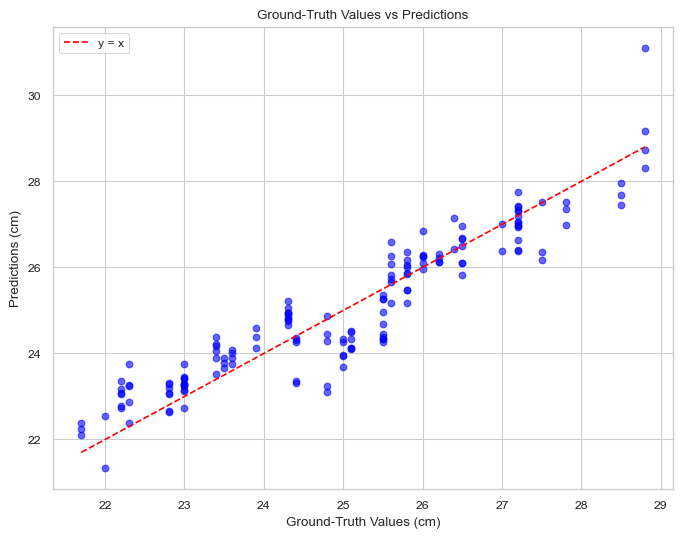

In [651]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=32, shuffle=True)

best_degree = 2

poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=best_degree)),
    ('linear_model', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred = poly_pipeline.predict(X_test)


collect_metrics(f"LinearRegression-PolyDegree-{best_degree}-scaled", y_pred, y_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='y = x')
plt.title("Ground-Truth Values vs Predictions")
plt.xlabel("Ground-Truth Values (cm)")
plt.ylabel("Predictions (cm)")
plt.legend()
plt.grid(True)

/var/folders/64/m87yf3yx7zngv12wrzgqgj_w0000gn/T/ipykernel_47692/2711333461.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(


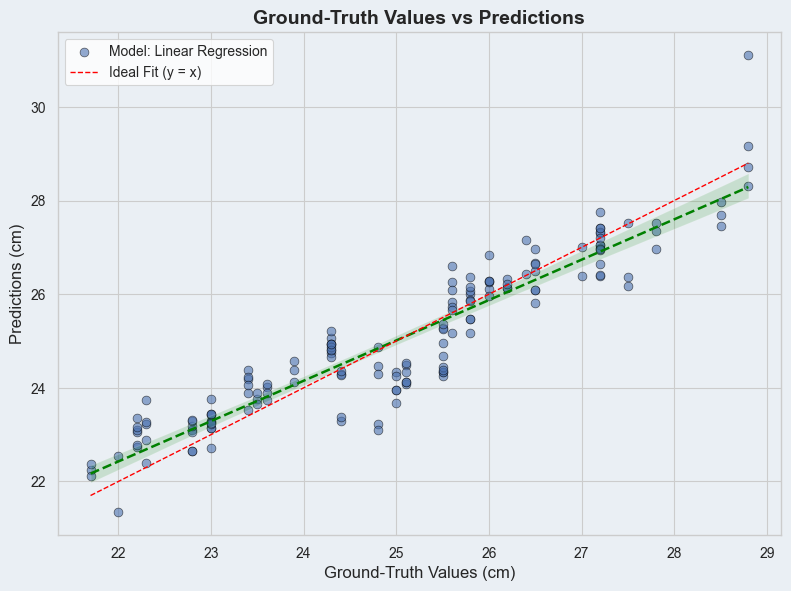

In [652]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Asegúrate de que y_test y y_pred están definidos previamente
# Si no están definidos, esto es un ejemplo:
# y_test = np.random.uniform(22, 29, 100)
# y_pred = y_test + np.random.normal(0, 0.8, 100)

def plot_regression_results(y_test, y_pred, model_name='Linear Regression'):
    # Crear el DataFrame
    df = pd.DataFrame({'Ground-Truth Values (cm)': y_test, 'Predictions (cm)': y_pred})

    # Estilo para artículo científico
    sns.set_theme(context="paper", style="whitegrid")  # Tema para visualización

    # Crear el gráfico con Seaborn

    plt.figure(figsize=(8, 6), facecolor='#eaeff4')  # Tamaño adecuado
    plt.gca().set_facecolor('#eaeff4')

    sns.regplot(
        x='Ground-Truth Values (cm)', 
        y='Predictions (cm)', 
        data=df,
        scatter_kws={
            'alpha': 0.6,  # Transparencia
            's': 40,  # Tamaño de los puntos
            'edgecolor': 'black',  # Borde de los puntos
            'linewidths': 0.5  # Grosor del borde de los puntos
        },
        line_kws={
            'color': 'green',  # Color de la línea
            'linestyle': '--'  # Estilo de la línea
        },
        label=f"Model: {model_name}"  # Etiqueta para la línea de regresión
    )

    # Línea de identidad (y = x)
    plt.plot(
        [df['Ground-Truth Values (cm)'].min(), df['Ground-Truth Values (cm)'].max()],
        [df['Ground-Truth Values (cm)'].min(), df['Ground-Truth Values (cm)'].max()],
        'k--', linewidth=1, label='Ideal Fit (y = x)', color='red'
    )

    # Etiquetas y título
    plt.xlabel('Ground-Truth Values (cm)', fontsize=12)  # Tamaño de letra del eje X
    plt.ylabel('Predictions (cm)', fontsize=12)  # Tamaño de letra del eje Y
    plt.title('Ground-Truth Values vs Predictions', fontsize=14, fontweight='bold')  # Título en negrita

    # Leyenda
    plt.legend(fontsize=10, loc='upper left', frameon=True)

    # Ticks de los ejes
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Ajustar márgenes
    plt.tight_layout()

    # Guardar la figura (opcional)
    plt.savefig(f"{model_name.strip()}_model.png", dpi=300)

    # Mostrar el gráfico
    plt.show()

plot_regression_results(y_test, y_pred,'Linear Regression')

In [653]:
print("predictions:", list(y_pred[:5]))
print("ground-truth values:", list(y_test[:5].values))

predictions: [25.05515134594894, 23.36331968399243, 23.76212326874495, 26.976684146782176, 24.37268174938702]
ground-truth values: [24.3, 22.2, 23.0, 27.2, 23.4]


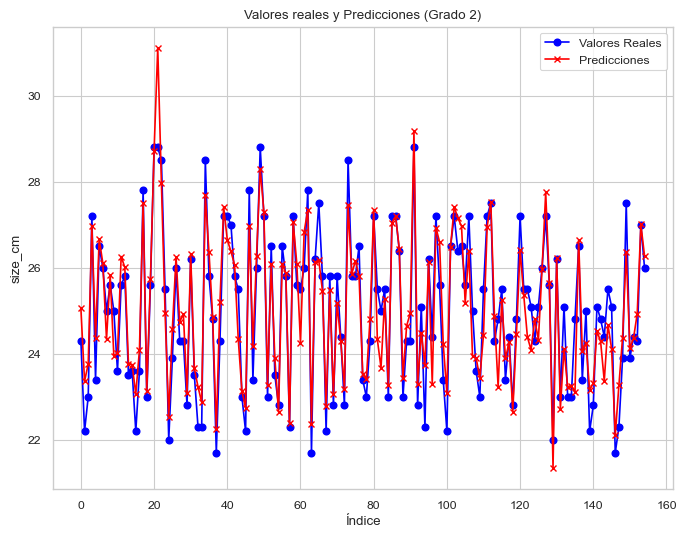

In [654]:
plt.figure(figsize=(8, 6))
plt.plot(range(len(y_test)), y_test, label='Valores Reales', color='blue', marker='o')
plt.plot(range(len(y_pred)), y_pred, label='Predicciones', color='red', marker='x')
plt.title(f"Valores reales y Predicciones (Grado {best_degree})")
plt.xlabel("Índice")
plt.ylabel("size_cm")
plt.legend()
plt.grid(True)
plt.show()

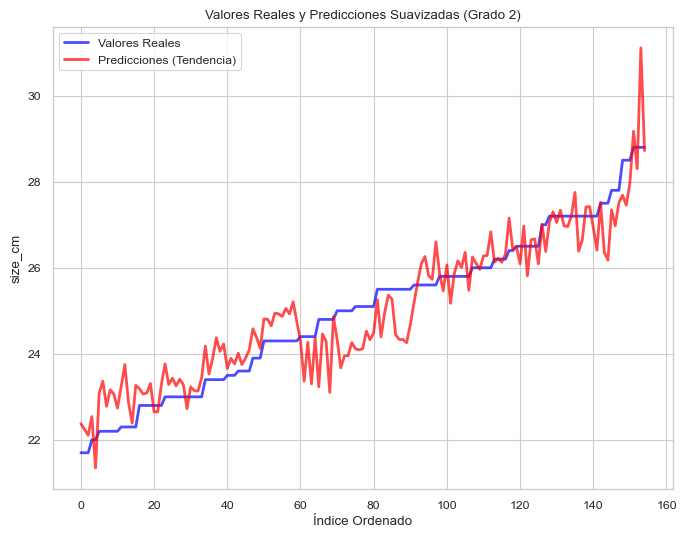

In [655]:
import numpy as np
import matplotlib.pyplot as plt

y_test_np = np.array(y_test)  # Convertir a NumPy
y_pred_np = np.array(y_pred)  # Convertir a NumPy

# Ordenar los valores
sorted_indices = np.argsort(y_test_np)
y_test_sorted = y_test_np[sorted_indices]
y_pred_sorted = y_pred_np[sorted_indices]

# Graficar valores reales y predicciones suavizadas
plt.figure(figsize=(8, 6))

# Valores reales (línea azul)
plt.plot(range(len(y_test_sorted)), y_test_sorted, label='Valores Reales', color='blue', linewidth=2, alpha=0.7)

# Predicciones suavizadas (línea roja)
plt.plot(range(len(y_pred_sorted)), y_pred_sorted, label='Predicciones (Tendencia)', color='red', linewidth=2, alpha=0.7)

# Personalizar el gráfico
plt.title(f"Valores Reales y Predicciones Suavizadas (Grado {best_degree})")
plt.xlabel("Índice Ordenado")
plt.ylabel("size_cm")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

### Checking the residuals

In [656]:
# residuals = y_test - y_pred

# # Crear un DataFrame con los datos originales del conjunto de prueba
# X_test_df = pd.DataFrame(X_test, columns=['width', 'height', 'coin_width', 'coin_height', 'foot_width', 'sex_M', 'foot_side_right'])

# # Agregar las columnas de valores reales, predicciones y residuales
# X_test_df['Actual'] = y_test
# X_test_df['Predicted'] = y_pred
# X_test_df['Residual'] = np.abs(residuals)

# results_df_sorted = X_test_df.sort_values(by='Residual', ascending=False)
# print("Top 10 worst predictions:")
# results_df_sorted.head(10)

In [657]:
# print(X_test_df.isnull().sum())
# print(residuals.isna().sum())
# print(y_test.isna().sum())

# X_test_df['Residual'].hist(bins=50)

In [658]:
# results_df_sorted[results_df_sorted['Residual'].isnull()].shape

In [659]:
# plt.figure(figsize=(10, 6))
# plt.scatter(range(len(residuals)), residuals, alpha=0.6, color='purple', label='Residuals')
# plt.axhline(0, color='red', linestyle='--', label='Zero Error Line')
# plt.xlabel("Index of Test Samples")
# plt.ylabel("Residual (Actual - Predicted)")
# plt.title("Residuals Analysis")
# plt.legend()
# plt.grid(True)
# plt.show()

### Ploting the degrees with one feature

In [660]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import LinearRegression

# rows, cols = 2, 2  # Ajusta las filas y columnas para los grados
# feature_to_eval = "width"
# feature_index = 0  # Índice correspondiente a "width" en X_train y X_test

# # Seleccionar una sola característica
# X_train_feature = X_train[:, feature_index].reshape(-1, 1)  # NumPy array
# X_test_feature = X_test[:, feature_index].reshape(-1, 1)  # NumPy array
# X_feature = X[feature_to_eval].values.reshape(-1, 1)  # pandas DataFrame

# # Crear rango continuo de valores para graficar
# X_range = np.linspace(X_feature.min(), X_feature.max(), 200).reshape(-1, 1)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_feature)
# X_test_scaled = scaler.transform(X_test_feature)
# X_range_scaled = scaler.transform(X_range)

# plt.figure(figsize=(10, 8))

# for degree in range(1, 5):
#     # Transformar la característica con PolynomialFeatures
#     poly = PolynomialFeatures(degree=degree)
#     X_train_poly = poly.fit_transform(X_train_scaled)
#     X_range_poly = poly.transform(X_range_scaled)  # Transformar rango continuo

#     # Ajustar el modelo con datos transformados
#     model = LinearRegression()
#     model.fit(X_train_poly, y_train)

#     # Predicciones para el rango continuo
#     y_range_pred = model.predict(X_range_poly)

#     # Subplot para el grado actual
#     plt.subplot(rows, cols, degree)
#     plt.scatter(X_feature, y, color='slateblue', label='Datos Originales', alpha=0.6)
#     plt.plot(X_range_scaled, y_range_pred, color='red', label=f'Grado {degree}', linewidth=2)
#     plt.title(f'Polinomio Grado {degree}')
#     plt.xlabel(feature_to_eval)
#     plt.ylabel('y')
#     plt.grid(True)
#     if degree == 1:  # Agregar leyenda solo una vez
#         plt.legend()

# plt.tight_layout()
# plt.show()

### Aplying PCA

-------model: LinearRegression-PCA-1-------
R²: 0.0011
MSE: 3.0618
RMSE: 1.7498

-------model: LinearRegression-PCA-2-------
R²: 0.0014
MSE: 3.0607
RMSE: 1.7495

-------model: LinearRegression-PCA-3-------
R²: -0.0020
MSE: 3.0714
RMSE: 1.7525

-------model: LinearRegression-PCA-4-------
R²: 0.6964
MSE: 0.9305
RMSE: 0.9646



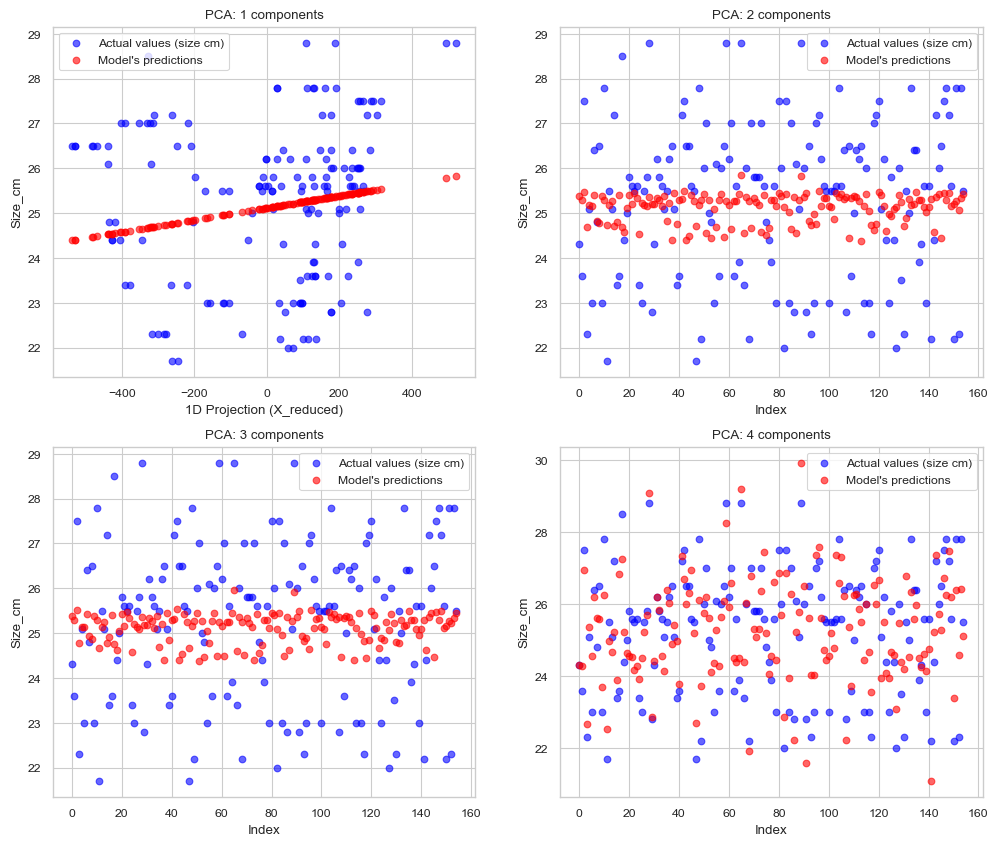

In [661]:
from sklearn.decomposition import PCA

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

fig, axes = plt.subplots(2,2, figsize=(12, 10))
axes = axes.ravel()

for idx, n_components in enumerate(range(1, 5)):
    # Reducir a 1 dimensión
    pca = PCA(n_components=n_components)
    X_train_reduced = pca.fit_transform(X_train)
    X_test_reduced = pca.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_reduced, y_train) 
    y_pred = model.predict(X_test_reduced)

    collect_metrics(f"LinearRegression-PCA-{n_components}", y_pred, y_test)

    ax = axes[idx]
    if n_components == 1:
        ax.scatter(X_test_reduced, y_test, color='blue', alpha=0.6, label='Actual values (size cm)')
        ax.scatter(X_test_reduced, y_pred, color='red', alpha=0.6, label="Model's predictions")
        ax.set_xlabel("1D Projection (X_reduced)")
    else:
        ax.scatter(range(len(y_test)), y_test, color='blue', alpha=0.6, label='Actual values (size cm)')
        ax.scatter(range(len(y_test)), y_pred, color='red', alpha=0.6, label="Model's predictions")
        ax.set_xlabel("Index")

    ax.set_title(f"PCA: {n_components} components")
    ax.set_ylabel("Size_cm")
    ax.legend()
    ax.grid(True)
plt.show()

### Applying Regularization

In [662]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [663]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge = Ridge(alpha=0.1).fit(X_train, y_train)
lasso = Lasso(alpha=0.1).fit(X_train, y_train)
elastic_net  = ElasticNet(alpha=0.1, l1_ratio=0.5).fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_elastic = elastic_net.predict(X_test)

collect_metrics("Ridge", y_pred_ridge, y_test)
collect_metrics("Lasso", y_pred_lasso, y_test)
collect_metrics("Elastic Net", y_pred_elastic, y_test)



-------model: Ridge-------
R²: 0.8304
MSE: 0.5200
RMSE: 0.7211

-------model: Lasso-------
R²: 0.8170
MSE: 0.5608
RMSE: 0.7489

-------model: Elastic Net-------
R²: 0.8201
MSE: 0.5513
RMSE: 0.7425



In [664]:
%pip install xgboost -q
%pip install lightgbm -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [665]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42).fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

collect_metrics("RandomForestRegressor",y_pred_rf, y_test)
collect_metrics("XGBRegressor",y_pred_xgb, y_test)


-------model: RandomForestRegressor-------
R²: 0.8790
MSE: 0.3710
RMSE: 0.6091

-------model: XGBRegressor-------
R²: 0.8811
MSE: 0.3646
RMSE: 0.6038



In [666]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=1.0, epsilon=0.01).fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
collect_metrics("SVR",y_pred_svr, y_test)

-------model: SVR-------
R²: 0.1030
MSE: 2.7494
RMSE: 1.6581



In [667]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=4).fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
collect_metrics("KNeighborsRegressor",y_pred_knn, y_test)

-------model: KNeighborsRegressor-------
R²: 0.6320
MSE: 1.1279
RMSE: 1.0620



In [668]:
%pip install tensorflow -q

Note: you may need to restart the kernel to use updated packages.


### Aplying Neural Networks

In [669]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

X_train_temp, X_test, y_train_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size=0.25, random_state=42)

nn_scaler = StandardScaler()
X_train = nn_scaler.fit_transform(X_train)
X_val = nn_scaler.transform(X_val)
X_test = nn_scaler.transform(X_test)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=0)

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

predictions = model.predict(X_test)


/Users/gipo/my-stuff/MIT/shoe-sizer/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Loss (MSE): 2.7541
Test MAE: 1.2486
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [670]:
collect_metrics("NeuralNetwork",predictions, y_test)

-------model: NeuralNetwork-------
R²: 0.0673
MSE: 2.7541
RMSE: 1.6595



In [671]:
results_df = pd.DataFrame(MODEL_RESULTS)
results_df

,model_name,r2,mse,rmse
0,LinearRegression,0.810536,0.620135,0.787487
1,LinearRegression-CV,0.823308,0.578330,0.760480
2,LinearRegression-PolyDegree-1,0.823308,0.578330,0.760480
3,LinearRegression-PolyDegree-2,0.823308,0.578330,0.760480
4,LinearRegression-PolyDegree-3,0.823308,0.578330,0.760480
5,LinearRegression-PolyDegree-4,0.823308,0.578330,0.760480
6,LinearRegression-PolyDegree-2-scaled,0.870027,0.425414,0.652238
7,LinearRegression-PCA-1,0.001088,3.061822,1.749806
8,LinearRegression-PCA-2,0.001448,3.060720,1.749491
9,LinearRegression-PCA-3,-0.002026,3.071368,1.752532


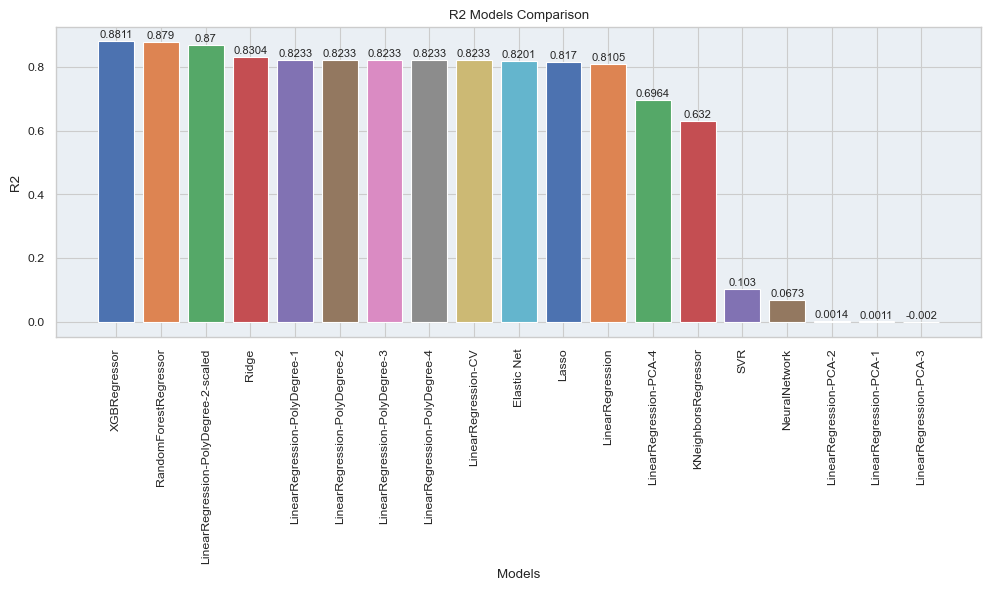

In [ ]:

results_df_sorted = results_df.sort_values(by='r2', ascending=False)
#results_df_sorted = results_df_sorted.iloc[:-1] # dropping the last row for better visualization

r2_values = results_df_sorted['r2']
models = results_df_sorted['model_name']

plt.figure(figsize=(10, 6))
plt.gca().set_facecolor('#eaeff4')
for model, r2 in zip(models, r2_values):
    plt.bar(model, r2, label=f"model: {model}")
    plt.text(model, r2 + 0.01, f"{round(r2, 4)}", ha='center', fontsize=8)
plt.xlabel('Models')
plt.ylabel('R2')
plt.title('R2 Models Comparison')
#plt.legend(bbox_to_anchor=(1, 1))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

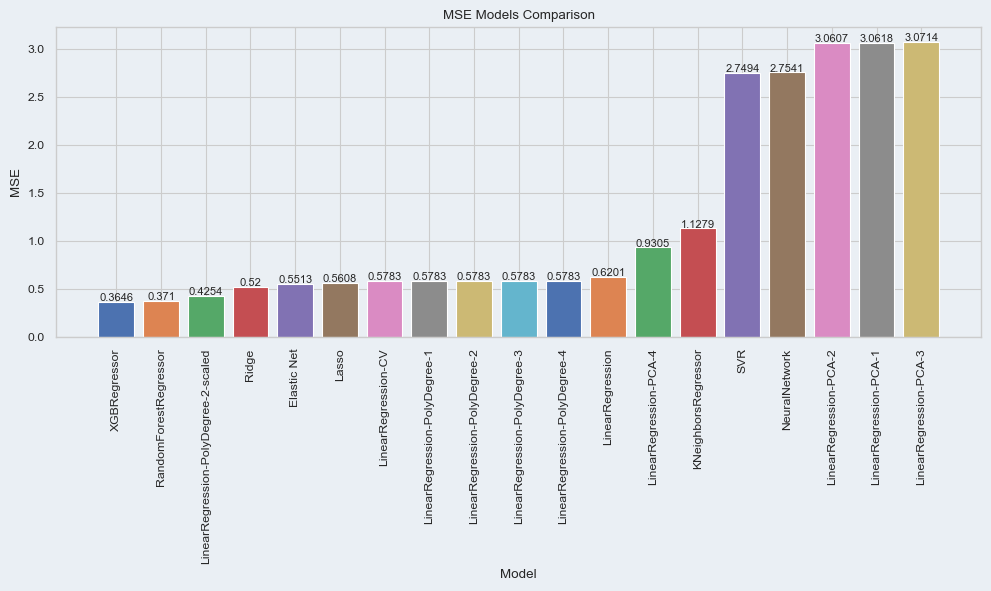

In [684]:

results_df_sorted = results_df.sort_values(by='mse', ascending=True)
#results_df_sorted = results_df_sorted.iloc[:-1] # dropping the last row for better visualization

metrics = results_df_sorted['mse']
models = results_df_sorted['model_name']

plt.figure(figsize=(10, 6), facecolor='#eaeff4')
plt.gca().set_facecolor('#eaeff4')
for model, mse in zip(models, metrics):
    plt.bar(model, mse, label=f"model: {model}")
    plt.text(model, mse + 0.01, f"{round(mse, 4)}", ha='center', fontsize=8)
plt.xlabel('Model')
plt.ylabel('MSE')
plt.title('MSE Models Comparison')
#plt.legend(bbox_to_anchor=(1, 1))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/var/folders/64/m87yf3yx7zngv12wrzgqgj_w0000gn/T/ipykernel_47692/2711333461.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(


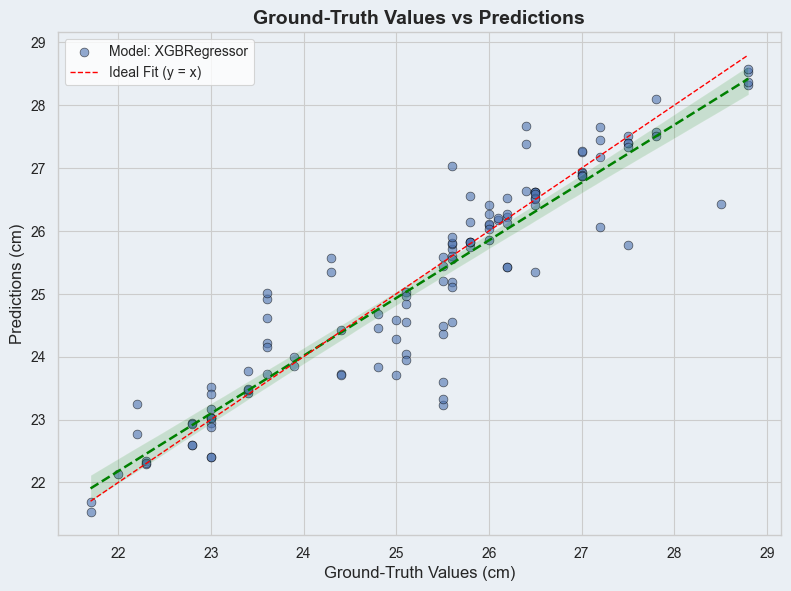

In [674]:
best_model = results_df_sorted.iloc[0]['model_name']

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42).fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# plt.figure(figsize=(8, 6))
# plt.scatter(y_test, y_pred_xgb, color='blue', alpha=0.6)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='y = x')
# plt.title("Model: XGBRegressor")
# plt.xlabel("Ground-Truth Values (cm)")
# plt.ylabel("Predictions (cm)")
# plt.legend()
# plt.grid(True)

plot_regression_results(y_test, y_pred_xgb, model_name=best_model)

In [675]:
y_test.shape, y_pred_xgb.shape

((124,), (124,))

### Checking the best model's residuals

In [676]:
residuals = y_test - y_pred_xgb

print(X_test.shape)
print(residuals.shape)

(124, 7)
(124,)


In [677]:

# Crear un DataFrame con los datos originales del conjunto de prueba
# X_test_original = scaler.inverse_transform(X_test)
X_test_df = pd.DataFrame(X_test, columns=['width', 'height', 'coin_width', 'coin_height', 'foot_width', 'sex_M', 'foot_side_right'])

# Agregar las columnas de valores reales, predicciones y residuales
X_test_df['Actual'] = y_test
X_test_df['Predicted'] = y_pred_xgb
X_test_df['Residual'] = residuals
X_test_df['Residual_abs'] = np.abs(residuals)

results_df_sorted = X_test_df.sort_values(by='Residual_abs', ascending=False)
print("Top 10 worst predictions:")
results_df_sorted.head(10)

Top 10 worst predictions:


,width,height,coin_width,coin_height,foot_width,sex_M,foot_side_right,Actual,Predicted,Residual,Residual_abs
86,0.59050,0.523361,1.534425,1.392598,0.598789,-1.072515,0.883122,27.5,22.586832,1.719040,1.719040
70,0.59050,0.523361,0.458447,0.400172,0.530052,0.932388,0.883122,25.6,25.823853,-1.433157,1.433157
39,-1.75495,-0.761406,-0.655958,-0.363233,-0.596174,-1.072515,-1.132346,24.3,23.474510,-1.271243,1.271243
2,0.59050,0.523361,0.996436,0.934555,1.629841,0.932388,-1.132346,27.2,27.515448,1.129859,1.129859
109,0.59050,0.523361,1.034864,0.858215,0.545915,-1.072515,-1.132346,25.1,24.610388,1.053470,1.053470
55,-1.75495,-0.761406,-1.078663,-1.012127,-1.050894,0.932388,0.883122,25.6,26.180828,1.048656,1.048656
49,0.59050,0.523361,0.420020,0.591023,0.091194,-1.072515,0.883122,24.3,23.243101,-1.044866,1.044866
10,0.59050,0.523361,-0.041114,-0.286892,0.228668,0.932388,0.883122,22.2,27.571772,-1.043101,1.043101
24,-1.75495,-2.046173,0.035742,-0.057871,-0.342376,-1.072515,-1.132346,22.2,23.779112,-0.574593,0.574593
118,0.59050,-2.062233,-1.655080,-1.737362,-1.130206,0.932388,-1.132346,25.1,26.876219,0.541912,0.541912


In [686]:
feet_df.iloc[86]

width          1600
height         1200
coin_width      169
coin_height     169
foot_width     1515
sex               M
foot_side      left
size_cm        27.5
Name: 86, dtype: object

In [687]:
full_feet_df.iloc[86]

img_name          42_robertb_left_30.jpeg
width                                1600
height                               1200
coin_width                            169
coin_height                           169
foot_width                           1515
bad_photo                               0
img_name_clean            42_robertb_left
name                      42_robertb_left
sex                                     M
foot_side                            left
size_cm                              27.5
size_eu                                42
Name: 86, dtype: object

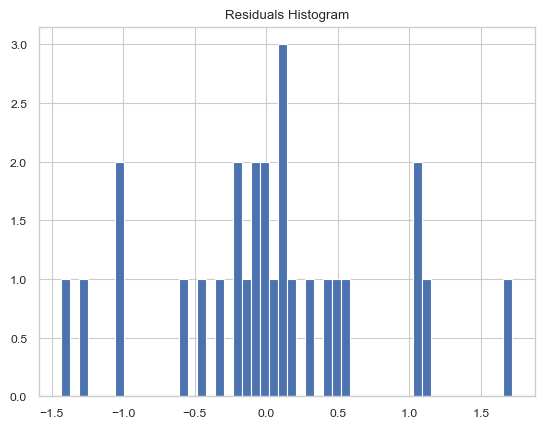

In [678]:
X_test_df['Residual'].hist(bins=50)
plt.title("Residuals Histogram")
plt.show()

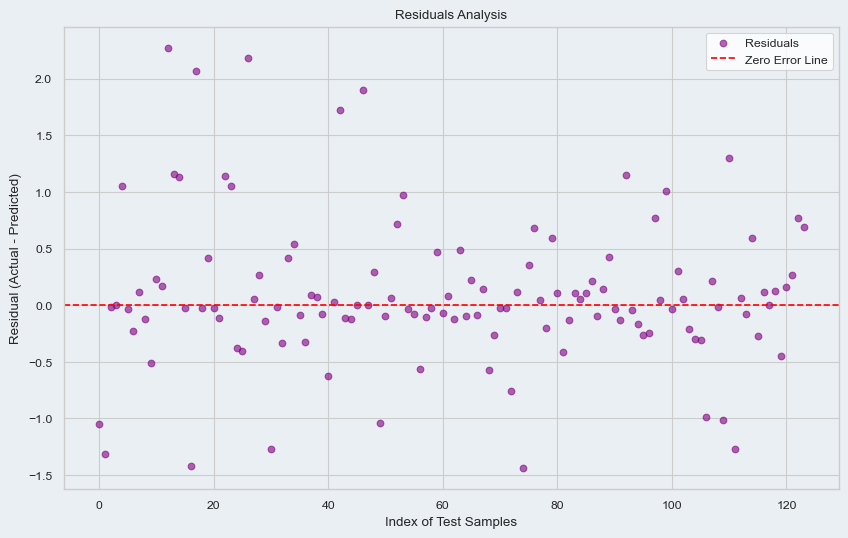

In [685]:

plt.figure(figsize=(10, 6), facecolor='#eaeff4')
plt.gca().set_facecolor('#eaeff4')
plt.scatter(range(len(residuals)), residuals, alpha=0.6, color='purple', label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Error Line')
plt.xlabel("Index of Test Samples")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals Analysis")
plt.legend()
plt.grid(True)
plt.show()

### Saving the best model

In [680]:
import joblib

best_model = xgb #poly_pipeline
best_model_name = 'shoe_sizer_model'
best_model_path = f'../models/{best_model_name}.pkl'

joblib.dump(best_model, f'{best_model_path}')

print(f"Modelo guardado en '{best_model_path}'")

Modelo guardado en '../models/shoe_sizer_model.pkl'
